# Ensemble : Bagging

## 1.환경준비

### (1) import

In [1]:
#라이브러리들을 불러오자.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 전처리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 모델링
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import * 
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

import warnings    # 경고메시지 제외
warnings.filterwarnings(action='ignore')

### (2) 데이터 준비

* 변수설명
    * COLLEGE : 대학 졸업여부
    * INCOME : 연수입
    * OVERAGE : 월평균 초과사용 시간(분)
    * LEFTOVER : 월평균 잔여시간비율(%)
    * HOUSE : 집값
    * HANDSET_PRICE : 스마트폰 가격
    * OVER_15MINS_CALLS_PER_MONTH : 월평균 장기통화(15분이상) 횟수
    * AVERAGE_CALL_DURATION : 평균 통화 시간
    * REPORTED_SATISFACTION : 만족도 설문조사 결과
    * REPORTED_USAGE_LEVEL : 사용도 자가진단 결과
    * CONSIDERING_CHANGE_OF_PLAN : 향후 변경계획 설문조사 결과
    * CHURN : 이탈(번호이동) 여부 (1-이탈, 0-잔류, Target 변수)


In [2]:
# 데이터를 불러옵시다.
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/mobile_cust_churn.csv'
data = pd.read_csv(path)
data = data.sample(5000, random_state = 2022)
data['CHURN'] = data['CHURN'].map({'LEAVE':1, 'STAY':0})
data.head()

,id,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION,REPORTED_USAGE_LEVEL,CONSIDERING_CHANGE_OF_PLAN,CHURN
3178,3179,0,119512,51,31,248566,229,5,2,very_sat,very_high,considering,1
14926,14927,1,142144,192,15,774317,581,29,4,unsat,very_little,never_thought,1
15116,15117,1,142308,0,79,306426,497,1,1,sat,little,considering,0
12733,12734,1,113385,0,0,333599,819,1,6,very_unsat,very_high,considering,1
14032,14033,1,90348,209,10,637286,360,26,4,unsat,little,actively_looking_into_it,0


## 2.데이터 준비

### (1) 데이터 정리

In [3]:
drop_cols = ['id']
data.drop(drop_cols, axis = 1, inplace = True )

### (2) 데이터분할1 : x, y 나누기

In [4]:
target = 'CHURN'
x = data.drop(target, axis = 1)
y = data.loc[:, target]

### (3) NA 조치

### (4) 가변수화

In [5]:
dumm_cols = ['REPORTED_SATISFACTION','REPORTED_USAGE_LEVEL','CONSIDERING_CHANGE_OF_PLAN']
x = pd.get_dummies(x, columns = dumm_cols, drop_first = True)

### (5) 데이터분할2 : train : validation

In [6]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3, random_state = 2022)

## 3.모델링 : 랜덤포레스트


In [7]:
# 모델 선언
model = RandomForestClassifier(n_estimators = 5, max_depth = 3) #트리 5개 만들어라, 기본값 100

In [8]:
# 학습
model.fit(x_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=5)

In [9]:
# 예측
pred = model.predict(x_val)

In [10]:
# 평가 -> 앙상블은 시각화해서 보는거에 의미가 없다.-> 볼수는 있음
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

           0       0.68      0.74      0.71       769
           1       0.70      0.64      0.67       731

    accuracy                           0.69      1500
   macro avg       0.69      0.69      0.69      1500
weighted avg       0.69      0.69      0.69      1500



## 4.시각화와 변수중요도

### (1) 모델의 내부를 살펴봅시다.

In [11]:
# 5개 decision tree
model.estimators_

[DecisionTreeClassifier(max_depth=3, max_features='auto',
                        random_state=1277683151),
 DecisionTreeClassifier(max_depth=3, max_features='auto', random_state=154816182),
 DecisionTreeClassifier(max_depth=3, max_features='auto', random_state=449109398),
 DecisionTreeClassifier(max_depth=3, max_features='auto', random_state=465847448),
 DecisionTreeClassifier(max_depth=3, max_features='auto',
                        random_state=1832789661)]

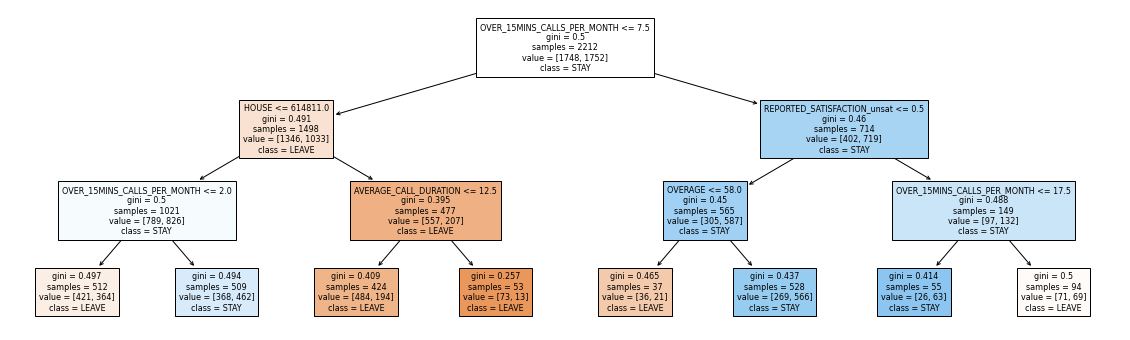

In [12]:
# 각 트리별로 시각화 할 수 있다. -> 추천X 의미없음
plt.figure(figsize=(20,6))
#첫번째 트리 보여줘
plot_tree(model.estimators_[0], 
               feature_names = x_train.columns,
               class_names= ['LEAVE','STAY'], 
               filled = True, fontsize = 8);

### (2) 변수 중요도

In [13]:
# 개별트리에 대한 변수 중요도
print(x_train.columns)
#전체의 변수 중요도
print(model.feature_importances_)

Index(['COLLEGE', 'INCOME', 'OVERAGE', 'LEFTOVER', 'HOUSE', 'HANDSET_PRICE',
       'OVER_15MINS_CALLS_PER_MONTH', 'AVERAGE_CALL_DURATION',
       'REPORTED_SATISFACTION_sat', 'REPORTED_SATISFACTION_unsat',
       'REPORTED_SATISFACTION_very_sat', 'REPORTED_SATISFACTION_very_unsat',
       'REPORTED_USAGE_LEVEL_high', 'REPORTED_USAGE_LEVEL_little',
       'REPORTED_USAGE_LEVEL_very_high', 'REPORTED_USAGE_LEVEL_very_little',
       'CONSIDERING_CHANGE_OF_PLAN_considering',
       'CONSIDERING_CHANGE_OF_PLAN_never_thought',
       'CONSIDERING_CHANGE_OF_PLAN_no', 'CONSIDERING_CHANGE_OF_PLAN_perhaps'],
      dtype='object')
[0.00000000e+00 2.54809490e-02 2.11951746e-01 3.24717998e-02
 4.22321017e-01 2.43336103e-02 2.32262870e-01 4.25690817e-02
 0.00000000e+00 4.89080285e-03 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.46875506e-05 0.00000000e+00 2.64926034e-03
 0.00000000e+00 0.00000000e+00 1.05417559e-03 0.00000000e+00]


* 변수중요도 그래프 그리기 함수 만들기

In [14]:
def plot_feature_importance(importance, names):
    feature_importance = np.array(importance)
    feature_names = np.array(names)

    data={'feature_names':feature_names,'feature_importance':feature_importance}
    fi_df = pd.DataFrame(data)

    fi_df.sort_values(by=['feature_importance'], ascending=False,inplace=True)
    fi_df.reset_index(drop=True, inplace = True)

    plt.figure(figsize=(10,8))
    sns.barplot(x='feature_importance', y='feature_names', data = fi_df)

    plt.xlabel('FEATURE IMPORTANCE')
    plt.ylabel('FEATURE NAMES')
    plt.grid()

    return fi_df

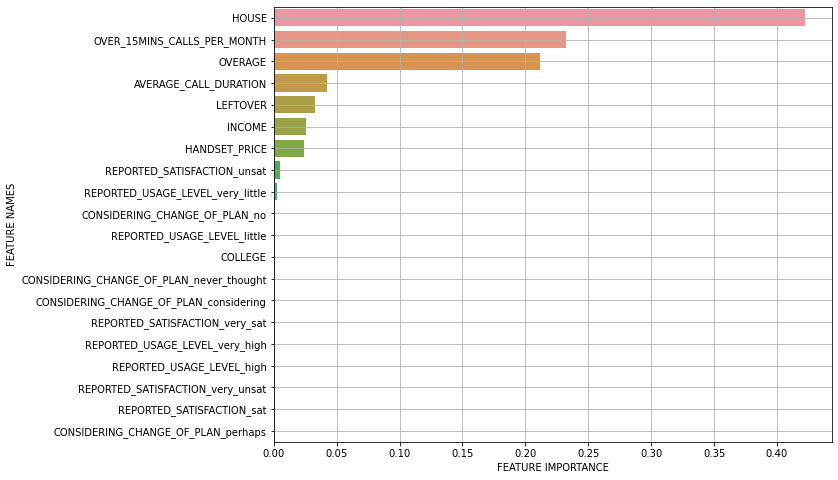

In [15]:
result = plot_feature_importance(model.feature_importances_, x_train.columns)

## 5.실습: random forest 튜닝

* grid search를 수행합니다.
    * ① n_estimators 의 갯수를 5 ~ 200까지 5개씩 증가시켜가며 튜닝해 봅시다.
    * ② max_features를 1 ~ feature갯수까지 1씩 증가시켜가며 튜닝해 봅시다.
    * ③ n_estimators, max_features를 동시에 튜닝.

* 모델링 후 cv 평가 결과를 차트로 그려봅시다. 
* 튜닝된 모델로 부터 변수중요도를 뽑아 봅시다.


### (3) n_estimators와 max_features를 한꺼번에 튜닝

In [16]:
x_train.shape

(3500, 20)

In [70]:
params={'n_estimators': range(60,200,10),'max_features':range(1,7,1)}

In [71]:
model3=RandomForestClassifier()

In [72]:
model3_gs=GridSearchCV(model3,params,cv=5,verbose=3)

In [74]:
model3_gs.fit(x_train,y_train)

Fitting 5 folds for each of 84 candidates, totalling 420 fits
[CV 1/5] END ................max_features=1, n_estimators=60; total time=   0.2s
[CV 2/5] END ................max_features=1, n_estimators=60; total time=   0.2s
[CV 3/5] END ................max_features=1, n_estimators=60; total time=   0.2s
[CV 4/5] END ................max_features=1, n_estimators=60; total time=   0.2s
[CV 5/5] END ................max_features=1, n_estimators=60; total time=   0.2s
[CV 1/5] END ................max_features=1, n_estimators=70; total time=   0.3s
[CV 2/5] END ................max_features=1, n_estimators=70; total time=   0.3s
[CV 3/5] END ................max_features=1, n_estimators=70; total time=   0.3s
[CV 4/5] END ................max_features=1, n_estimators=70; total time=   0.2s
[CV 5/5] END ................max_features=1, n_estimators=70; total time=   0.3s
[CV 1/5] END ................max_features=1, n_estimators=80; total time=   0.3s
[CV 2/5] END ................max_features=1, n_

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_features': range(1, 7),
                         'n_estimators': range(60, 200, 10)},
             verbose=3)

In [75]:
pred3 = model3_gs.predict(x_val)

In [76]:
print(classification_report(y_val,pred3))

              precision    recall  f1-score   support

           0       0.72      0.73      0.73       769
           1       0.71      0.71      0.71       731

    accuracy                           0.72      1500
   macro avg       0.72      0.72      0.72      1500
weighted avg       0.72      0.72      0.72      1500



In [77]:
# 튜닝 결과를 데이터프레임으로 저장 
result = pd.DataFrame(model3_gs.cv_results_) 
temp = result.loc[:, ['param_n_estimators','param_max_features', 'mean_test_score']] 
temp.head()

,param_n_estimators,param_max_features,mean_test_score
0,60,1,0.660286
1,70,1,0.654571
2,80,1,0.654571
3,90,1,0.661429
4,100,1,0.653429


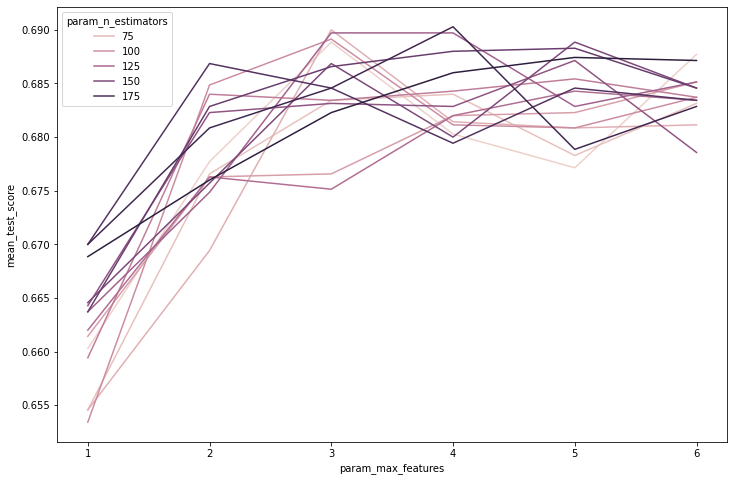

In [81]:
plt.figure(figsize=(12,8))
sns.lineplot(x='param_max_features',y='mean_test_score',data=temp,hue='param_n_estimators') #트리의 개수는 100-200정도면 충분해
#plt.plot('param_n_estimators','mean_test_score',data=temp,marker='o')
#plt.grid()
plt.show()

### (2) max_features 튜닝

In [47]:
x_train.shape #1~20개 조절가능

(3500, 20)

In [48]:
params={'max_features':range(1,21)}

In [49]:
model2=RandomForestClassifier()
model2_gs=GridSearchCV(model2,params,cv=5,verbose=3)

In [50]:
model2_gs.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END .................................max_features=1; total time=   0.5s
[CV 2/5] END .................................max_features=1; total time=   0.4s
[CV 3/5] END .................................max_features=1; total time=   0.4s
[CV 4/5] END .................................max_features=1; total time=   0.4s
[CV 5/5] END .................................max_features=1; total time=   0.5s
[CV 1/5] END .................................max_features=2; total time=   0.5s
[CV 2/5] END .................................max_features=2; total time=   0.5s
[CV 3/5] END .................................max_features=2; total time=   0.5s
[CV 4/5] END .................................max_features=2; total time=   0.5s
[CV 5/5] END .................................max_features=2; total time=   0.6s
[CV 1/5] END .................................max_features=3; total time=   0.6s
[CV 2/5] END .................................m

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_features': range(1, 21)}, verbose=3)

In [51]:
pred2 = model2_gs.predict(x_val)

In [52]:
print(classification_report(y_val,pred2))

              precision    recall  f1-score   support

           0       0.73      0.72      0.72       769
           1       0.71      0.71      0.71       731

    accuracy                           0.72      1500
   macro avg       0.72      0.72      0.72      1500
weighted avg       0.72      0.72      0.72      1500



* 변수 중요도

In [53]:
# 튜닝 결과를 데이터프레임으로 저장 
result = pd.DataFrame(model2_gs.cv_results_) 
temp = result.loc[:, ['param_max_features', 'mean_test_score']] 
temp.head()

,param_max_features,mean_test_score
0,1,0.666000
1,2,0.683143
2,3,0.682857
3,4,0.680857
4,5,0.679714


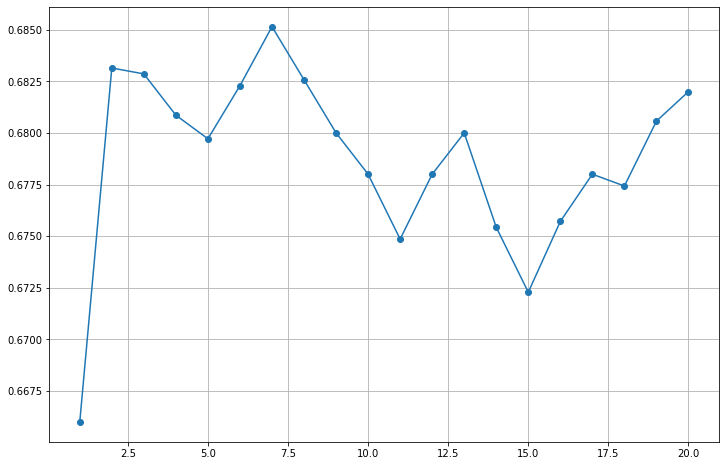

In [55]:
plt.figure(figsize=(12,8))
plt.plot('param_max_features','mean_test_score',data=temp,marker='o') #트리의 개수는 100-200정도면 충분해
plt.grid()
plt.show()

+ max_feauters default = 루트 features

### (1) n_estimators

In [56]:
params={'n_estimators': range(5,201,5)}

In [57]:
m=RandomForestClassifier()

In [58]:
m_gs=GridSearchCV(m,params,cv=5)

In [59]:
m_gs.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'n_estimators': range(5, 201, 5)})

In [60]:
m_gs.best_params_,m_gs.best_score_ #트리 60개 만들면 좋아

({'n_estimators': 165}, 0.6951428571428571)

In [61]:
pred2 = m_gs.predict(x_val)

In [62]:
print(classification_report(y_val,pred2))

              precision    recall  f1-score   support

           0       0.73      0.70      0.71       769
           1       0.70      0.73      0.71       731

    accuracy                           0.71      1500
   macro avg       0.71      0.71      0.71      1500
weighted avg       0.71      0.71      0.71      1500



+ 튜닝 결과를 그래프로 그려보기

In [63]:
#튜닝 결과를 데이터 프레임으로 저장하기
result=pd.DataFrame(m_gs.cv_results_)
result.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.041691,0.007983,0.004994,0.000169,5,{'n_estimators': 5},0.618571,0.628571,0.631429,0.657143,0.631429,0.633429,0.012765,40
1,0.071808,0.007595,0.007597,0.001337,10,{'n_estimators': 10},0.618571,0.668571,0.645714,0.630000,0.672857,0.647143,0.021131,39
2,0.107365,0.001484,0.009639,0.003997,15,{'n_estimators': 15},0.650000,0.712857,0.645714,0.680000,0.657143,0.669143,0.024852,36
3,0.154548,0.024630,0.017712,0.005304,20,{'n_estimators': 20},0.664286,0.678571,0.670000,0.640000,0.665714,0.663714,0.012860,38
4,0.179336,0.012572,0.018060,0.004542,25,{'n_estimators': 25},0.644286,0.690000,0.667143,0.665714,0.670000,0.667429,0.014524,37


In [64]:
temp=result.loc[:,['param_n_estimators','mean_test_score']]
temp.head()

,param_n_estimators,mean_test_score
0,5,0.633429
1,10,0.647143
2,15,0.669143
3,20,0.663714
4,25,0.667429


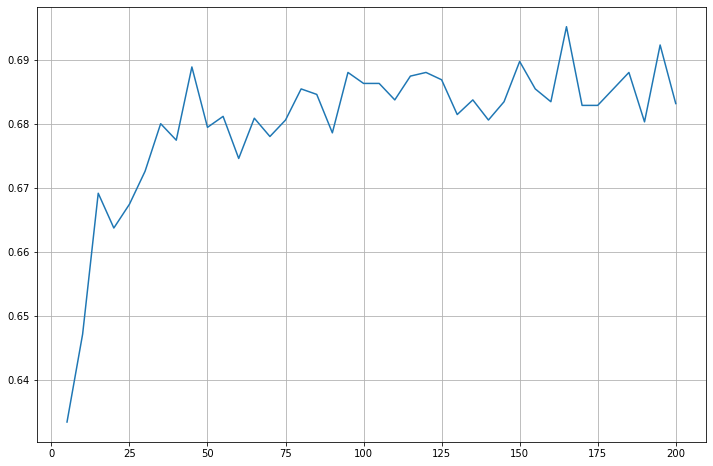

In [65]:
plt.figure(figsize=(12,8))
plt.plot('param_n_estimators','mean_test_score',data=temp) #트리의 개수는 100-200정도면 충분해
plt.grid()
plt.show()

경향을 보는게 중요  
데이터 건수를 늘려도 n_estimators는 수평 유지 -> 트리를 많이 만들어도 의미 없음, 적당히 만들자 -> elbow method  
경향을 그려서 꼭 확인하자  
RF는 트리가 많아진다고 모델이 복잡하지 않음 -> 오히려 트리가 많으면 과적합을 방지함  